# Test: Heater 1D continuo — N₂ en tubo vacío

Verifica el modelo del heater en modo **PRF** (flujo en pistolón, N=21 celdas):
un único paso de simulación continuo, informe de balances y visualización de perfiles.

Equivalente estructural de `test_psa_01_steps_adsorption` para el heater.

| Adsorber (`runner_adsorption.py`)               | Heater (`runner_heater.py`)                     |
|-------------------------------------------------|-------------------------------------------------|
| `run_step(step, sv0, t_max, params)`            | `run_step(sv0, t_max, params)` — sin `step`    |
| Ergun (lecho empaquetado)                       | Darcy-Weisbach (tubo vacío)                     |
| Fase gas + sólido: `C, q, Hg, Ts`              | Solo fase gas: `C, Hg`                          |
| `epsi` = 0.3–0.4                               | `epsi` = 1 (sin relleno)                        |
| Cinética LDF + isotermas                        | Sin adsorción                                   |
| `build_column_results` → `col`                  | `build_heater_results` → `heater`               |
| `adsorber_balances.balance_report`              | `heater_balances.balance_report`                |

## 1. Imports

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.units.heater.config.gas_props  import build_gas_prop_config
from src.units.heater.config.boundary_c import build_boundary_c_config
from src.units.heater.config.thermal_bc import build_thermal_bc_config
from src.units.heater.config.transport  import build_transport_config
from src.units.heater.config.initial_c  import build_initial_c_config
from src.units.heater.state             import pack_state_vector

from src.solvers.runner_heater          import run_step
from src.postprocessing.heater_balances import balance_report
from src.postprocessing.variables_plot  import (
    Graph_P, Graph_Tg, Graph_v,
    Graph_y, Graph_y_i,
    Graph_C, Graph_C_i,
)

DB_PATH = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")

print("Imports OK")
print("gasdb existe:", os.path.isfile(DB_PATH))

Imports OK
gasdb existe: True


## 2. Parámetros del sistema

In [2]:
# ── Geometría ───────────────────────────────────────────────────────────────
N       = 51
L       = 0.75          # m
Di      = 0.08          # m  (radio interno 4 cm)
Do      = 0.09          # m  (radio externo 4.5 cm)
e_wall  = (Do - Di) / 2.0
dz      = L / N
Ai      = 0.25 * np.pi * Di**2
Pi      = np.pi * Di
Po      = np.pi * Do

# ── Gas ─────────────────────────────────────────────────────────────────────
nc      = 1
SPECIES = ["N2"]

# ── Condiciones de operación ─────────────────────────────────────────────────
P_INIT  = 1.01325       # bar (1 atm)
P_OUT   = 1.01325       # bar
T_INIT  = 403.0         # K
T_IN    = 403.0         # K
Q_VOL   = 0 / 3600.0    # m3/s  (6 L/h)
V_IN    = Q_VOL / Ai    # m/s  velocidad superficial en entrada
Q_WALL  = 5.0          # W   potencia total calentamiento pared

# ── Integración ──────────────────────────────────────────────────────────────
T_MAX   = 300         # s
N_SEC   = 5
RTOL    = 1.0e-8
ATOL    = 1.0e-10

print(f"Geometria : L={L} m  Di={Di} m  Do={Do} m  N={N}  dz={dz:.4f} m")
print(f"Gas       : {SPECIES}  nc={nc}")
print(f"Flujo     : Q={Q_VOL*3600*1e3:.1f} L/h  V_in={V_IN:.3e} m/s")
print(f"Pared     : Q_wall={Q_WALL} W  (heatfluxwall)")
print(f"CI/CC     : P={P_INIT:.5f} bar  T={T_INIT} K")

Geometria : L=0.75 m  Di=0.08 m  Do=0.09 m  N=51  dz=0.0147 m
Gas       : ['N2']  nc=1
Flujo     : Q=0.0 L/h  V_in=0.000e+00 m/s
Pared     : Q_wall=5.0 W  (heatfluxwall)
CI/CC     : P=1.01325 bar  T=403.0 K


## 3. Construcción del modelo

Los cinco bloques `build_*` más el empaquetado del estado inicial.

In [3]:
# 1. Propiedades del gas
prop_gas = build_gas_prop_config(
    species=SPECIES, mode="constant", n_comp=nc, N=N,
    T_ref=T_INIT, db_path=DB_PATH,
)
gas_T_ref = float(np.min(np.asarray(prop_gas["Tref"])))

# 2. Condiciones de contorno
bc_config = build_boundary_c_config(
    n_comp=nc,
    v_in=V_IN,
    T_in=T_IN,
    y_in=np.array([1.0]),
    P_out=P_OUT,
)

# 3. Condición térmica de pared  (calor fijo distribuido uniformemente)
thermal_bc = build_thermal_bc_config(
    mode="heatfluxwall",
    Di=Di, Do=Do, e_wall=e_wall,
    Qwall=Q_WALL,
)

# 4. Transporte  (correlación de Nusselt para h_wall)
trans_config = build_transport_config(mode="correlation", N=N)

# 5. Condiciones iniciales
y_init  = np.ones((nc, N), dtype=float)   # y_N2 = 1
P_init  = np.full(N, P_INIT)
Tg_init = np.full(N, T_INIT)

init_config = build_initial_c_config(
    P_init=P_init, Tg_init=Tg_init, y_init=y_init,
    n_comp=nc, N=N, prop_gas=prop_gas, gas_T_ref=gas_T_ref,
)

sv0 = pack_state_vector(
    C=init_config["C_init"],
    Hg=init_config["Hg_init"],
)

# ── Dict de parámetros del solver ──────────────────────────────────────────
params = {
    "n_comp":           nc,
    "N":                N,
    "dz":               dz,
    "Ai":               Ai,
    "Di":               Di,
    "Pi":               Pi,
    "Po":               Po,
    "prop_gas":         prop_gas,
    "MW":               np.asarray(prop_gas["MW"]),
    "gas_T_ref":        gas_T_ref,
    "bc_config":        bc_config,
    "trans_config":     trans_config,
    "thermal_bc_config":thermal_bc,
    "energy":           True,
    "prop_update_mode": "always",
    "trans_update_mode":"always",
    "species":          SPECIES,
    "_cache":           {},
}

print(f"sv0.shape = {sv0.shape}  (nc+1)*N = ({nc}+1)*{N} = {(nc+1)*N}")
print(f"C_init N2 media : {init_config['C_init'][0].mean():.4f} mol/m3")
print(f"Hg_init media   : {init_config['Hg_init'].mean():.2f} J/m3")
print("Modelo construido OK")

sv0.shape = (102,)  (nc+1)*N = (1+1)*51 = 102
C_init N2 media : 30.2397 mol/m3
Hg_init media   : 447560.13 J/m3
Modelo construido OK


## 4. Simulación — calentamiento continuo

Equivalente a `run_step(step='ads', ...)` del adsorber, pero sin argumento `step`.

In [4]:
t0 = time.perf_counter()
t_arr, y_hist, heater = run_step(
    sv0=sv0, t_max=T_MAX, params=params,
    solver="solve_ivp", rtol=RTOL, atol=ATOL,
    n_sec=N_SEC, show_progress=True,
)
wall_time = time.perf_counter() - t0

print(f"\nIntegracion completada en {wall_time:.2f} s de CPU")
print(f"Puntos temporales         : {len(t_arr)}")
print(f"heater._y_results.shape   : {heater._y_results.shape}   (n_t, nc, N)")
print(f"P media final [bar]       : {heater._P_results[-1, :].mean():.5f}")
print(f"Tg media final [K]        : {heater._Tg_results[-1, :].mean():.4f}")
print(f"Tg salida final [K]       : {heater._Tg_results[-1, -1]:.4f}")
print(f"v media final [m/s]       : {heater._v_results[-1, :].mean():.4e}")

heater:   0%|          | 0.0/300 s [00:00<?, ?s/s]


Integracion completada en 2.64 s de CPU
Puntos temporales         : 1501
heater._y_results.shape   : (1501, 1, 51)   (n_t, nc, N)
P media final [bar]       : 2.14320
Tg media final [K]        : 852.4166
Tg salida final [K]       : 852.4166
v media final [m/s]       : 0.0000e+00


## 5. Balance de conservación

Verifica masa y energía acumuladas frente a flujos integrados en los contornos.

In [5]:
df_bal = balance_report(heater, params, include_energy=True, print_report=True)
df_bal

──────────────────────────────────────────────────────────────────────────────────
  INFORME DE BALANCE DE CONSERVACIÓN — HEATER
──────────────────────────────────────────────────────────────────────────────────
               Acumulación  Flujo neto BC  Error abs  Error rel [%]
Variable                                                           
N_N2 [mol]              +0             +0         +0             +0
N_total [mol]           +0             +0         +0             +0
E_gas [kJ]            +1.5      -0.020829    -1.5208        -101.39
──────────────────────────────────────────────────────────────────────────────────
  Error máximo: 101.389 %  →  REVISAR    (>5 %)

  Desglose de términos energéticos [kJ]:
    Ein             = +0
    Eout            = +0
    Qcond_g_net     = -1.521  (conducción gas en contornos)
    Qwall           = +1.5  (calor gas↔pared)
    ΔE_gas          = +1.5
──────────────────────────────────────────────────────────────────────────────────


,Acumulación,Flujo neto BC,Error abs,Error rel [%]
Variable,,,,
N_N2 [mol],+0,+0,+0,+0
N_total [mol],+0,+0,+0,+0
E_gas [kJ],+1.5,-0.020829,-1.5208,-101.39


## 6. Visualización — Perfiles escalares

Layout estándar: **Entrada** (serie temporal) | **Perfil axial** (multi-tiempo) | **Salida** (serie temporal).
`plot_every` como lista de floats selecciona los snapshots más cercanos a esos instantes.

C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\GasifierSimNet\src\postprocessing\variables_plot.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


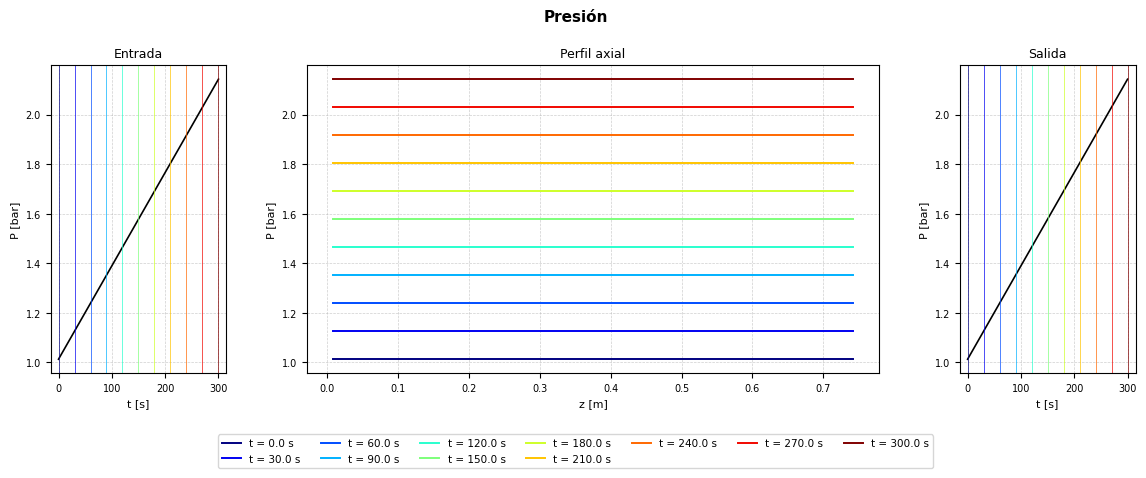

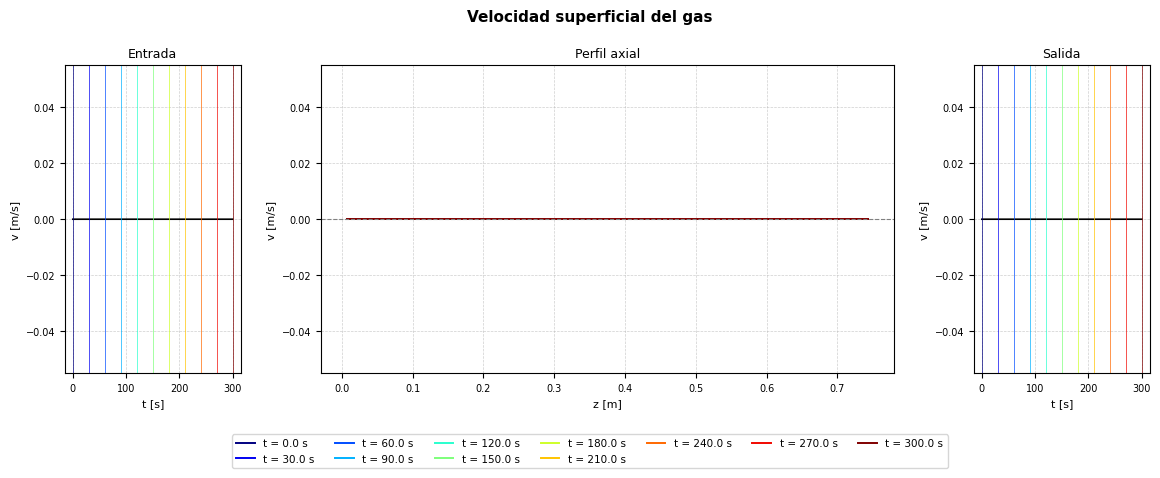

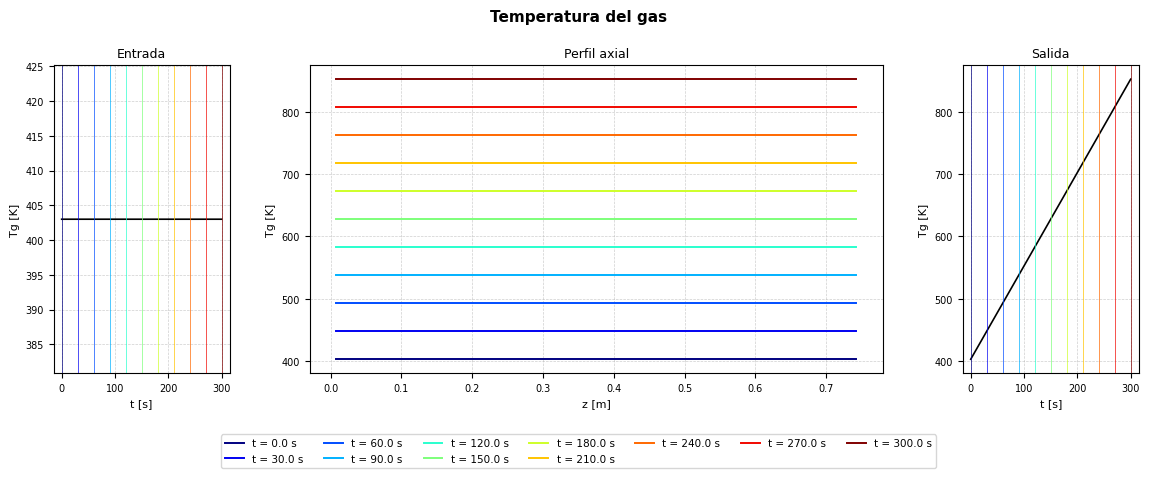

(<Figure size 1400x400 with 3 Axes>,
 (<Axes: title={'center': 'Entrada'}, xlabel='t [s]', ylabel='Tg [K]'>,
  <Axes: title={'center': 'Perfil axial'}, xlabel='z [m]', ylabel='Tg [K]'>,
  <Axes: title={'center': 'Salida'}, xlabel='t [s]', ylabel='Tg [K]'>))

In [6]:
PLOT_TIMES = [float(t) for t in range(0, int(T_MAX) + 1, 30)]

Graph_P(heater,  plot_every=PLOT_TIMES)
Graph_v(heater,  plot_every=PLOT_TIMES)
Graph_Tg(heater, plot_every=PLOT_TIMES)

## 7. Visualización — Composición

Para N2 puro (nc=1) la fracción molar es constante (= 1),
pero la concentración molar varía con la temperatura según la ley del gas ideal.

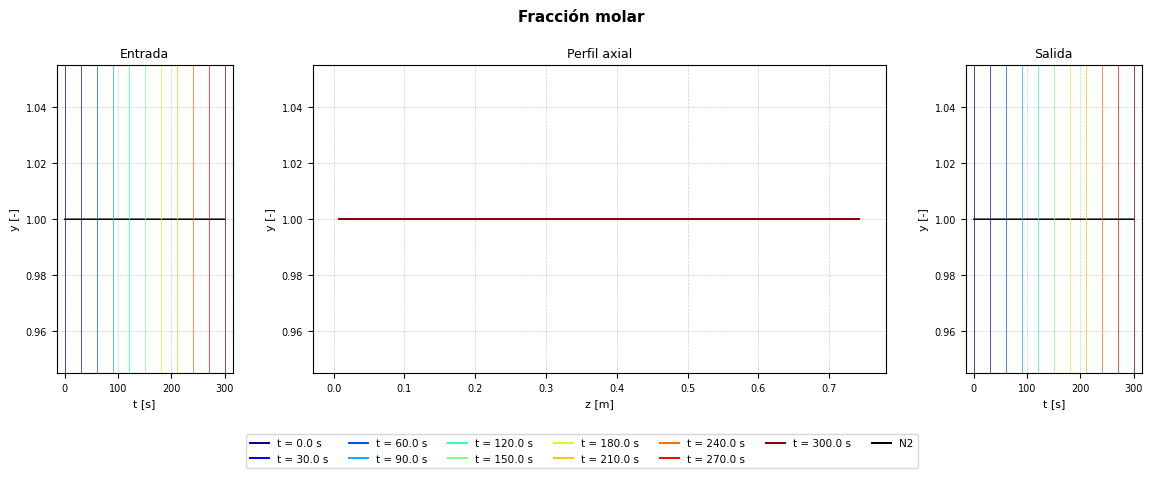

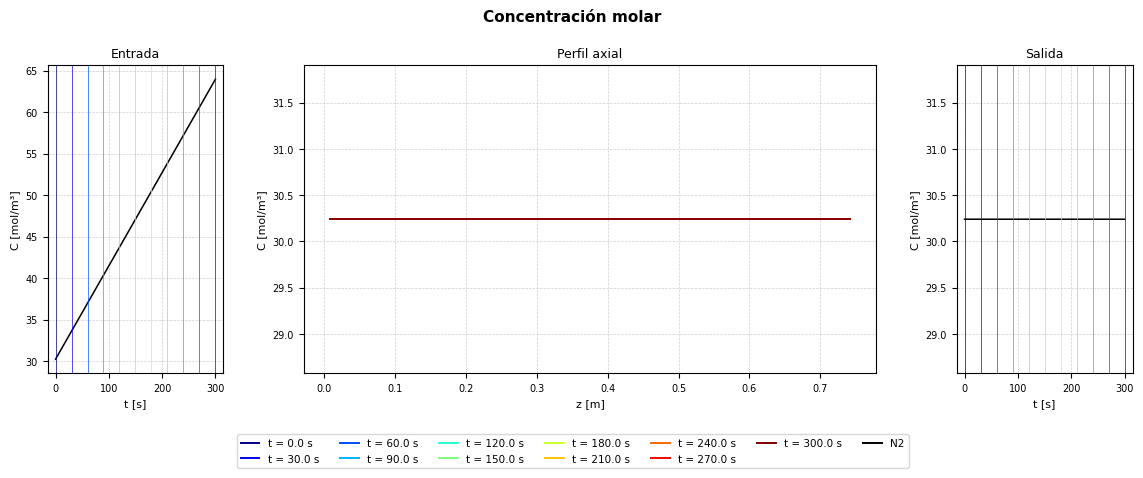

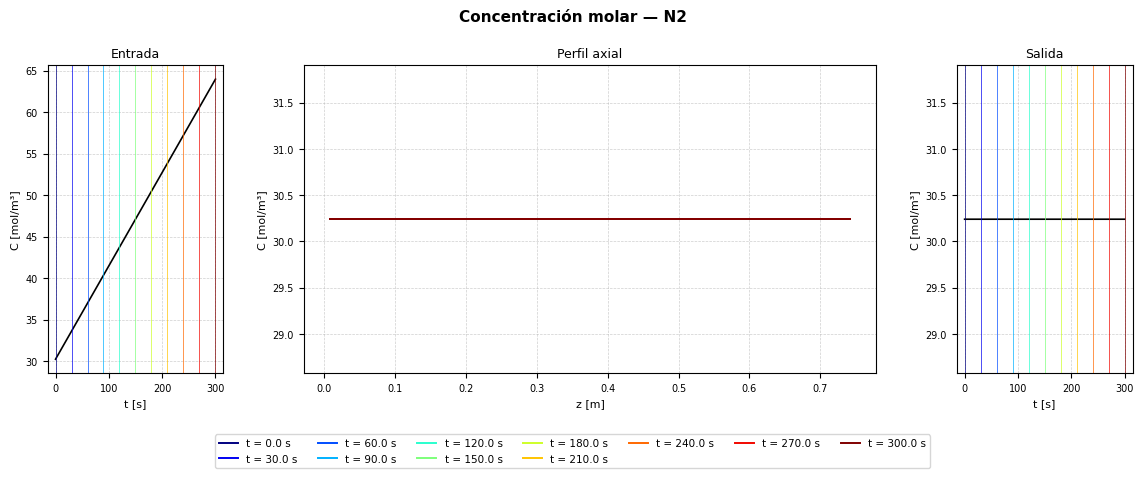

(<Figure size 1400x400 with 3 Axes>,
 (<Axes: title={'center': 'Entrada'}, xlabel='t [s]', ylabel='C [mol/m³]'>,
  <Axes: title={'center': 'Perfil axial'}, xlabel='z [m]', ylabel='C [mol/m³]'>,
  <Axes: title={'center': 'Salida'}, xlabel='t [s]', ylabel='C [mol/m³]'>))

In [7]:
Graph_y(heater,   plot_every=PLOT_TIMES)
Graph_C(heater,   plot_every=PLOT_TIMES)
Graph_C_i(heater, species_idx=0, plot_every=PLOT_TIMES)

## 8. Resumen final

In [8]:
print("=" * 65)
print(f"  RESUMEN -- HEATER PRF N2  ({T_MAX:.0f} s)")
print("=" * 65)
print(f"  Tiempo de computo          : {wall_time:.2f} s")
print(f"  Puntos temporales          : {len(t_arr)}")
print(f"  Celdas espaciales          : {N}")
print()
print(f"  Estado final (media axial):")
print(f"    P  [bar]  : {heater._P_results[-1, :].mean():.5f}")
print(f"    Tg [K]    : {heater._Tg_results[-1, :].mean():.4f}")
print(f"    Tg_out [K]: {heater._Tg_results[-1, -1]:.4f}")
print(f"    v  [m/s]  : {heater._v_results[-1, :].mean():.4e}")
print()
print(f"  Balances de conservacion:")
for row_key, label in [
    ("N_total [mol]",    "Error molar total  "),
    ("E_gas [kJ]",       "Error energia gas  "),
]:
    try:
        val = df_bal.loc[row_key, "Error rel [%]"]
        print(f"    {label}: {val:+.4f} %")
    except Exception:
        pass
print("=" * 65)

  RESUMEN -- HEATER PRF N2  (300 s)
  Tiempo de computo          : 2.64 s
  Puntos temporales          : 1501
  Celdas espaciales          : 51

  Estado final (media axial):
    P  [bar]  : 2.14320
    Tg [K]    : 852.4166
    Tg_out [K]: 852.4166
    v  [m/s]  : 0.0000e+00

  Balances de conservacion:
    Error molar total  : +0.0000 %
    Error energia gas  : -101.3886 %
